# ML LAB-5
# Name: Sneha Kanjwani
# CMS ID: 023-24-0273
# Section: H
# GitHub: https://github.com/snehakanjwani30/Machine-Learning-Labs
# Kaggle: https://www.kaggle.com/snehakanjwani
# Dataset: House Prices - Advanced Regression Techniques
# Dataset Source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

# Part 1 — Dataset, Problem & Feature/Target Identification

In [1]:
#TASK-1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("train.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
print("\nDataset information:")
df.info()
print("\nSummary statistics:")
df.describe()
#The code imports the required libraries and loads the `train.csv` dataset. It displays the dataset shape and first five rows 
#to understand its size, data, and columns. It also shows the dataset information, including column names, data types, 
#and non-null values, along with summary statistics such as count, mean, minimum, and maximum values for numerical columns.


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 1

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The dataset has 1,460 houses and 81 columns. The average SalePrice is around $181,000, with prices ranging from about $35,000 to $755,000. 
Some columns like LotFrontage, Alley, and MasVnrType have many missing values, but the features I selected do not have missing values.

In [3]:
#TASK-2
numerical_features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "GarageArea",
    "TotRmsAbvGrd"
]
categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]
target = "SalePrice"
print("Numerical Independent Variables:")
print(numerical_features)
print("Categorical Independent Variables:")
print(categorical_features)
print("Dependent Variable:")
print(target)
#This code separates the selected independent variables into numerical and categorical features. It defines `SalePrice` as 
#the dependent variable and prints the selected independent and dependent variables.
# I chose features a buyer would care about: size, quality, age, garage, rooms, neighborhood, style and kitchen quality.

Numerical Independent Variables:
['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', '1stFlrSF', 'GarageArea', 'TotRmsAbvGrd']
Categorical Independent Variables:
['Neighborhood', 'HouseStyle', 'KitchenQual']
Dependent Variable:
SalePrice


# Task 3: 
This is a regression problem because SalePrice is a continuous numerical value that we want to predict. Unlike classification, where we measure accuracy for categories, regression is evaluated using measures such as MAE, MSE, RMSE, and R².

# Part 2 — Data Preparation & Train/Test Split

In [5]:
#TASK-4
X = df[numerical_features + categorical_features]
y = df["SalePrice"]
print("X shape:", X.shape)
print("y shape:", y.shape)
X = pd.get_dummies(X, columns = categorical_features, 
                 drop_first=True, dtype=int)
print("X shape after encoding:", X.shape)
X.head()
#The code creates `X` using the selected numerical and categorical features, while `y` contains the `SalePrice` values. 
#It checks their shapes to confirm the number of rows and columns. The categorical features are then converted into numerical 0/1 columns 
#using one-hot encoding. The first category is removed using `drop_first=True` to avoid unnecessary duplicate information. 
#Finally, the updated shape and first few rows of `X` are displayed.
# Encoding gave 43 numeric columns (9 numerical + 34 dummies), with no missing values.

X shape: (1460, 12)
y shape: (1460,)
X shape after encoding: (1460, 43)


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,1stFlrSF,GarageArea,TotRmsAbvGrd,Neighborhood_Blueste,...,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,1710,7,856,2,2003,2,856,548,8,0,...,0,0,0,0,1,0,0,0,1,0
1,1262,6,1262,2,1976,2,1262,460,6,0,...,0,1,0,0,0,0,0,0,0,1
2,1786,7,920,2,2001,2,920,608,6,0,...,0,0,0,0,1,0,0,0,1,0
3,1717,7,756,3,1915,1,961,642,7,0,...,0,0,0,0,1,0,0,0,1,0
4,2198,8,1145,3,2000,2,1145,836,9,0,...,0,0,0,0,1,0,0,0,1,0


Neighborhood and HouseStyle have no natural order, so I used one-hot encoding. Label encoding would wrongly suggest one neighborhood is bigger than another. KitchenQual has an order (Fa < TA < Gd < Ex), but I used one-hot so the model learns a separate effect for each level. drop_first=True avoids duplicate information.

In [6]:
#TASK-5
print("Total missing values in X:",X.isnull().sum().sum())
print('Non-numeric columns:')
print(X.select_dtypes(exclude='number').columns.tolist())
print('Data types:')
print(X.dtypes.value_counts())
#This code checks `X` for missing values and non-numeric columns. It also displays the data types to confirm that all features 
# are numeric and ready for the next steps.

Total missing values in X: 0
Non-numeric columns:
[]
Data types:
int64    43
Name: count, dtype: int64


In [7]:
#TASK-6
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, 
                                                    random_state=42)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
#The dataset is divided into 80% training data and 20% testing data. The training data is used to train the Linear Regression model, 
# while the testing data is used to evaluate its performance on unseen house data.


X_train shape: (1168, 43)
X_test shape: (292, 43)
y_train shape: (1168,)
y_test shape: (292,)


# Part 3 — Linear Regression & Predictions

In [8]:
#TASK-7
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print('Linear Regression model trained successfully.')
#This code creates a Linear Regression model and trains it using the training data. After training, it prints a 
# message confirming that the model was trained successfully.

Linear Regression model trained successfully.


In [9]:
#TASK-8
y_pred = model.predict(X_test)
print('Predictions generated successfully!')
print('First 10 predictions:')
print(y_pred[:10])
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
comparison.head(10)
#A Multiple Linear Regression model was trained using the 43 prepared features. The model was then used to predict house prices 
#for the 292 test houses. A comparison table was created to compare the actual prices with the predicted prices for the first 10 houses.
#Most predictions are close (325,000 vs about 324,000), but some are far off (311,500 vs about 235,700).

Predictions generated successfully!
First 10 predictions:
[139611.763086   324212.78570488 112785.60607059 175375.6827452
 316134.68046087  66674.41918156 235741.48608559 145564.51660119
  66246.74918066 120464.10483917]


,Actual Price,Predicted Price
0,154500,139611.763086
1,325000,324212.785705
2,115000,112785.606071
3,159000,175375.682745
4,315500,316134.680461
5,75500,66674.419182
6,311500,235741.486086
7,146000,145564.516601
8,84500,66246.749181
9,135500,120464.104839


# Part 4 — Coefficients & Intercept

In [10]:
#TASK-9
print('Intercept:', model.intercept_)
coefficients = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient': model.coef_
})
coefficients

Intercept: -419970.9861393161


,Feature,Coefficient
0,GrLivArea,66.044767
1,OverallQual,13104.207968
2,TotalBsmtSF,11.953296
3,GarageCars,9416.205513
4,YearBuilt,213.835000
5,FullBath,-640.620632
6,1stFlrSF,-23.647367
7,GarageArea,8.189418
8,TotRmsAbvGrd,1566.830843
9,Neighborhood_Blueste,3610.036300


In [11]:
units = {
    'GrLivArea': 'square foot of living area',
    'OverallQual': 'point of overall quality (1-10 scale)',
    'TotalBsmtSF': 'square foot of basement',
    'GarageCars': 'garage car space',
    'YearBuilt': 'year of newer construction',
    'FullBath': 'full bathroom',
    '1stFlrSF': 'square foot of first floor',
    'GarageArea': 'square foot of garage',
    'TotRmsAbvGrd': 'room above ground',
}
refs = {'Neighborhood': 'Blmngtn', 'HouseStyle': '1.5Fin', 'KitchenQual': 'Ex'}

def interpret_feature(feature, coefficient):
    if feature in units:
        direction = "increase" if coefficient > 0 else "decrease"
        return (f"Each additional {units[feature]} is associated with a price {direction} of about "
                f"${abs(coefficient):,.0f}, holding other features constant.")
    col, level = feature.split("_", 1)
    higher_lower = "higher" if coefficient > 0 else "lower"
    return (f"A house with {col} = {level} is priced about ${abs(coefficient):,.0f} {higher_lower} "
            f"than the reference category ({refs[col]}), holding other features constant.")

coefficients["Interpretation"] = [interpret_feature(f, c) for f, c in zip(coefficients["Feature"], coefficients["Coefficient"])]
coefficients
#The coefficients show the estimated relationship between each feature and the predicted SalePrice while keeping other features constant. 
#A positive coefficient indicates an increase in predicted price, while a negative coefficient indicates a decrease. For numerical features, 
#the coefficient represents the approximate price change for a one-unit increase. For categorical features, it represents the estimated price 
#difference compared with the reference category.
#Higher quality, more living area, more garage space and a newer house raise price. FullBath and 1stFlrSF are negative because of 
# multicollinearity: 1stFlrSF is correlated with GrLivArea and TotalBsmtSF.

,Feature,Coefficient,Interpretation
0,GrLivArea,66.044767,Each additional square foot of living area is ...
1,OverallQual,13104.207968,Each additional point of overall quality (1-10...
2,TotalBsmtSF,11.953296,Each additional square foot of basement is ass...
3,GarageCars,9416.205513,Each additional garage car space is associated...
4,YearBuilt,213.835000,Each additional year of newer construction is ...
5,FullBath,-640.620632,Each additional full bathroom is associated wi...
6,1stFlrSF,-23.647367,Each additional square foot of first floor is ...
7,GarageArea,8.189418,Each additional square foot of garage is assoc...
8,TotRmsAbvGrd,1566.830843,Each additional room above ground is associate...
9,Neighborhood_Blueste,3610.036300,A house with Neighborhood = Blueste is priced ...


# TASK-10
The intercept does not have a meaningful real-world interpretation because it represents the predicted house price when all numerical features are zero and categorical variables are at their reference levels. This does not represent a realistic house.The intercept is about -$420,000, a negative price, so it is only a mathematical starting point.


# Part 5 — Residuals & Regression Metrics

In [12]:
#TASK-11
residuals = y_test - y_pred
print('First 10 residuals:')
print(residuals.head(10))

First 10 residuals:
892     14888.236914
1105      787.214295
413      2214.393929
522    -16375.682745
1036     -634.680461
614      8825.580818
218     75758.513914
1160      435.483399
649     18253.250819
887     15035.895161
Name: SalePrice, dtype: float64


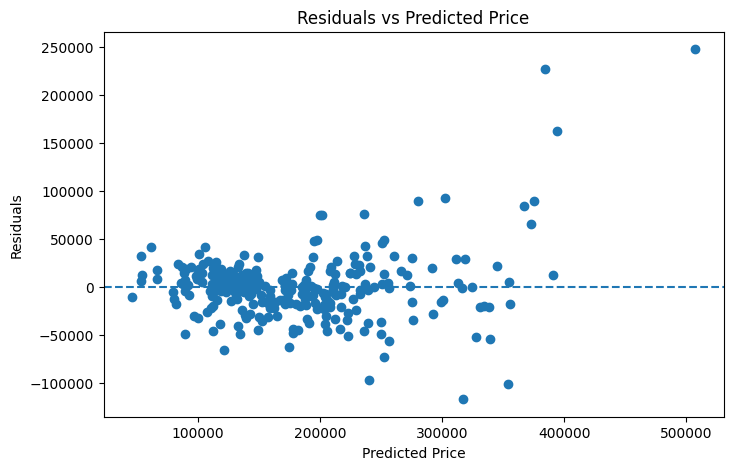

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Price')
plt.show()

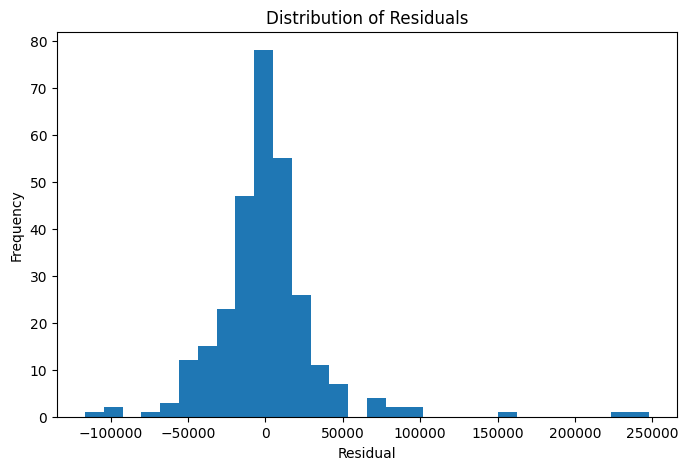

In [14]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

In the residual plot, most houses predicted below about $250,000 have errors within roughly ±$50,000, but the spread gets wider as the predicted price rises (a funnel shape). A few large positive residuals, up to about +$250,000, mean the model under-predicts some expensive houses. The histogram is centered near zero with a long right tail from those outliers. So the residuals are not perfectly random.

In [15]:
#TASK-12
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
metrics = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R^2'],
    'Value':[mae,mse,rmse,r2]
})
metrics
#This code calculates the model's performance using MAE, MSE, RMSE, and R². It then stores the results in a table so the model's performance 
# can be easily evaluated.
#The model is off by about $21,262 on average (MAE) and about $35,083 in RMSE. R² is 0.84, so it explains about 84% of price variation.

,Metric,Value
0,MAE,2.126220e+04
1,MSE,1.230844e+09
2,RMSE,3.508338e+04
3,R^2,8.395318e-01


# TASK-13
MAE shows the average absolute error in the predicted house prices and is easy to understand because it is in dollars. MSE calculates the average squared error and gives more importance to large errors. RMSE is the square root of MSE and is also expressed in dollars. R² shows how much of the variation in house prices is explained by the model.

For a non-technical stakeholder, MAE is the easiest metric to understand because it directly shows the average prediction error in dollars.
RMSE is also in dollars, but a few large errors inflate it. MAE reads simply as 'off by about $21,000 on average'

# Part 6 — Training vs. Testing & Generalization

In [16]:
#TASK-14
train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

comparison_metrics = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R^2'],
    'Training':[train_mae, train_mse, train_rmse, train_r2],
    'Testing':[mae,mse,rmse,r2]
})
comparison_metrics
#This code calculates the same four metrics on the training set and places them
# next to the test-set metrics so the two can be compared.

,Metric,Training,Testing
0,MAE,2.062546e+04,2.126220e+04
1,MSE,1.050206e+09,1.230844e+09
2,RMSE,3.240689e+04,3.508338e+04
3,R^2,8.239253e-01,8.395318e-01


# TASK-15
There is no large gap between the training and testing performance. The R² values are 0.824 for training and 0.840 for testing, while the RMSE values are also close. This suggests that the model is not strongly overfitting and performs reasonably well on unseen data.Test R² is slightly higher than training R², but test RMSE (about $35,100) is a bit worse than training RMSE (about $32,400). The difference comes from the test houses having a different price spread, not from better generalization

# Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

In [17]:
pd.Series(model.coef_ * X_train.std().values, index=X.columns).abs().sort_values(ascending=False).head(10)

GrLivArea               34636.034546
KitchenQual_TA          26728.035875
KitchenQual_Gd          21730.848720
OverallQual             17921.567177
Neighborhood_NridgHt    13009.043020
Neighborhood_NoRidge    12802.082623
HouseStyle_1Story        9676.194051
1stFlrSF                 9143.851916
Neighborhood_Crawfor     9084.621157
KitchenQual_Fa           8587.484748
dtype: float64

# TASK-16
Raw coefficients cannot be compared directly because the features have different units. I used standard deviation to make the comparison fair. GrLivArea has the biggest influence at about $34,600, followed by KitchenQual at about $26,700 and $21,700, and OverallQual at about $17,900. Neighborhoods like NridgHt and NoRidge have effects of around $13,000. Dummy variables depend on their reference category, so they are not directly comparable with numerical features.


# TASK-17
The Linear Regression model performs reasonably well, with a test R² of about 0.84, MAE of $21,000, and RMSE of $35,000. MAE is easy to understand because it shows the average prediction error in dollars.

GrLivArea has the strongest effect on price, followed by KitchenQual and OverallQual. The model has some limitations because it may not capture complex patterns. Some expensive houses also have larger prediction errors. Overall, the model scored 0.16955 on Kaggle and was ranked 2779. As a next step, I would try log-transforming the price and compare the model with Ridge, Lasso, and Random Forest.

In [18]:
#TASK-18
test_df = pd.read_csv('test.csv')
print('Test shape:',test_df.shape)

Test shape: (1459, 80)


In [19]:
X_test_kaggle = test_df[numerical_features + categorical_features].copy()
X_test_kaggle["KitchenQual"] = X_test_kaggle["KitchenQual"].fillna(df["KitchenQual"].mode()[0])

In [20]:
X_test_kaggle = pd.get_dummies(
    X_test_kaggle, columns=categorical_features,
    drop_first = True, dtype=int
)

In [21]:
X_test_kaggle = X_test_kaggle.reindex(columns=X.columns, fill_value=0)
print('Missing values:',X_test_kaggle.isnull().sum().sum())

Missing values: 3


In [22]:
for col in ["TotalBsmtSF", "GarageCars", "GarageArea"]:
    X_test_kaggle[col] = X_test_kaggle[col].fillna(X[col].median())

print("Missing values:", X_test_kaggle.isnull().sum().sum())

Missing values: 0


In [23]:
test_predictions = model.predict(X_test_kaggle)
print("Negative predictions:", (test_predictions < 0).sum())

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})
submission.to_csv("submission.csv", index=False)
print("submission.csv created successfully!")

sample = pd.read_csv("sample_submission.csv")
print("Rows match:", submission.shape == sample.shape)
print("Columns match:", list(submission.columns) == list(sample.columns))
submission.head()

Negative predictions: 0
submission.csv created successfully!
Rows match: True
Columns match: True


,Id,SalePrice
0,1461,116937.836659
1,1462,160385.309459
2,1463,158629.892959
3,1464,180928.680933
4,1465,249563.175175


This code loads the test dataset and prepares it using the same features and encoding as the training data. It handles the missing values and uses the trained model to predict house prices. Finally, it creates submission.csv with the house IDs and predicted prices for submission. It also checks that the number of rows and column names match the sample submission format.


# TASK-19
I submitted my submission.csv file to the Kaggle House Prices competition. My public leaderboard score was **0.16955** and my rank was **2779**. It was interesting to see how my Linear Regression model performed compared with submissions from other participants.
